# HW4 — Question 3: Poisson GLM on `Smokers_Age.xlsx`

**IEOR 4578 — Forecasting**
Luca Barattini (UNI: LB3656)

This notebook runs the Poisson-regression block from `GLM.py` on the smokers-age mortality dataset, as requested in Q3.


## Question statement

Run the GLM Poisson Regression code from `GLM.py` on `Smokers_Age.xlsx` and discuss the summary results. [20 points]


## Background — the dataset

| Column        | Meaning |
|---------------|---------|
| `AgeGroup`    | String label (e.g. `35 – 44`) — not used in the model |
| `Agecat`      | Integer age-group index (1 … 5) |
| `Smoke`       | Binary: 1 if smoker, 0 if non-smoker |
| `Agecatsq`    | $(\text{Agecat})^2$ — quadratic age effect |
| `Smokeage`    | Interaction term: `Agecat × Smoke` |
| `PersonYears` | Exposure: person-years of follow-up in that cell |
| `Deaths`      | Observed count of deaths (target) |

Because `Deaths` is a **count** bounded below at 0, an ordinary linear regression is not appropriate. A **Poisson GLM** with a log link is the standard choice:

$$\log \mathbb{E}[\text{Deaths}_i] \;=\; \beta_0 + \beta_1 \text{Agecat}_i + \beta_2 \text{Smoke}_i + \beta_3 \text{Agecatsq}_i + \beta_4 \text{Smokeage}_i + \beta_5 \log(\text{PersonYears}_i)$$

`PersonYears` enters as $\log(\text{PersonYears})$ so that, with its coefficient near 1, it acts as an **exposure offset** — i.e. deaths scale roughly linearly with person-years of observation.


In [1]:
# Imports — only what Q3 needs
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.width", 120)

os.makedirs("images", exist_ok=True)


In [2]:
# Load the data
ds = pd.read_excel('Datasets/Smokers_Age.xlsx')
print("Shape  :", ds.shape)
print("Columns:", list(ds.columns))
ds


Shape  : (10, 7)
Columns: ['AgeGroup', 'Agecat', 'Smoke', 'Agecatsq', 'Smokeage', 'PersonYears', 'Deaths']


,AgeGroup,Agecat,Smoke,Agecatsq,Smokeage,PersonYears,Deaths
0,35 – 44,1,1,1,1,52407,32
1,45 – 54,2,1,4,2,43248,104
2,55 - 64,3,1,9,3,28612,206
3,65 - 74,4,1,16,4,12663,186
4,75 - 84,5,1,25,5,5317,102
5,35 – 44,1,0,1,0,18790,2
6,45 – 54,2,0,4,0,10673,12
7,55 - 64,3,0,9,0,5710,28
8,65 - 74,4,0,16,0,2585,28
9,75 - 84,5,0,25,0,1462,31


## Fit the Poisson GLM

Following `GLM.py`, we log-transform `PersonYears` *in place* and fit the Poisson family via the formula API. The formula includes all five quantitative predictors; the log-transformed `PersonYears` behaves as an exposure offset with a coefficient very close to 1.


In [3]:
# Log-transform PersonYears (in place, as in GLM.py)
ds['PersonYears'] = np.log(ds['PersonYears'])

poisson_results = smf.glm(
    formula = 'Deaths ~ Agecat + Smoke + Agecatsq + Smokeage + PersonYears',
    data    = ds,
    family  = sm.families.Poisson()
).fit()

print(poisson_results.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                 Deaths   No. Observations:                   10
Model:                            GLM   Df Residuals:                        4
Model Family:                 Poisson   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -28.260
Date:                Fri, 10 Apr 2026   Deviance:                       1.4517
Time:                        17:49:41   Pearson chi2:                     1.39
No. Iterations:                     6   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -8.7447      4.803     -1.821      

### Key summary statistics (extracted programmatically for the write-up)


In [4]:
summary_stats = {
    'n observations'   : int(poisson_results.nobs),
    'Df Model'         : int(poisson_results.df_model),
    'Df Residuals'     : int(poisson_results.df_resid),
    'Log-Likelihood'   : poisson_results.llf,
    'Deviance'         : poisson_results.deviance,
    'Pearson chi2'     : float(poisson_results.pearson_chi2),
    'AIC'              : poisson_results.aic,
    'BIC'              : poisson_results.bic,
}
for k, v in summary_stats.items():
    print(f"{k:20s} = {v}")

# Coefficient table with SE, z, p, 95% CI
coef_table = pd.DataFrame({
    'Parameter' : poisson_results.params.index,
    'Coef'      : poisson_results.params.values,
    'Std err'   : poisson_results.bse.values,
    'z'         : poisson_results.tvalues.values,
    'P>|z|'     : poisson_results.pvalues.values,
    'IRR = exp(Coef)'     : np.exp(poisson_results.params.values),
    'Significant (α=0.05)': poisson_results.pvalues.values < 0.05,
})
print()
print(coef_table.to_string(index=False, float_format=lambda v: f'{v:12.6f}'))


n observations       = 10
Df Model             = 5
Df Residuals         = 4
Log-Likelihood       = -28.259840653009313
Deviance             = 1.4517408212638878
Pearson chi2         = 1.3925113507644107
AIC                  = 68.51968130601863
BIC                  = -7.758599550712296

  Parameter         Coef      Std err            z        P>|z|  IRR = exp(Coef)  Significant (α=0.05)
  Intercept    -8.744715     4.802910    -1.820712     0.068651         0.000159                 False
     Agecat     2.392673     0.212677    11.250266     0.000000        10.942708                  True
      Smoke     1.778510     0.876579     2.028922     0.042466         5.921027                  True
   Agecatsq    -0.221038     0.061162    -3.613998     0.000302         0.801686                  True
   Smokeage    -0.312943     0.099347    -3.150009     0.001633         0.731291                  True
PersonYears     0.783657     0.505655     1.549787     0.121193         2.189465               

/Users/lucabarattini/Coding/IEOR-4578/.venv/lib/python3.14/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.
  warnings.warn(


### Interpreting the coefficients

- **Intercept** — log expected deaths when every other regressor is zero (has no direct physical meaning here since `Agecat=0` is outside the data).
- **Agecat**, **Agecatsq** — a quadratic effect of age on the log-death-rate. A positive `Agecat` and non-zero `Agecatsq` together indicate that death risk grows faster than linearly with age.
- **Smoke** — additive log-rate shift for smokers at the baseline age.
- **Smokeage** — interaction: how the smoker vs. non-smoker gap *changes* with age.
- **PersonYears** — log exposure; its coefficient should be close to 1, meaning deaths scale ~proportionally to person-years (standard Poisson-offset behaviour).
- **IRR = exp(Coef)** — the Incidence-Rate Ratio: multiplicative change in expected deaths per unit change of the regressor.


## Visual — Expected vs Observed deaths

Two panels, exactly matching `GLM.py`: smokers (rows 0–4) on top, non-smokers (rows 5–9) on the bottom, plotted against age category.


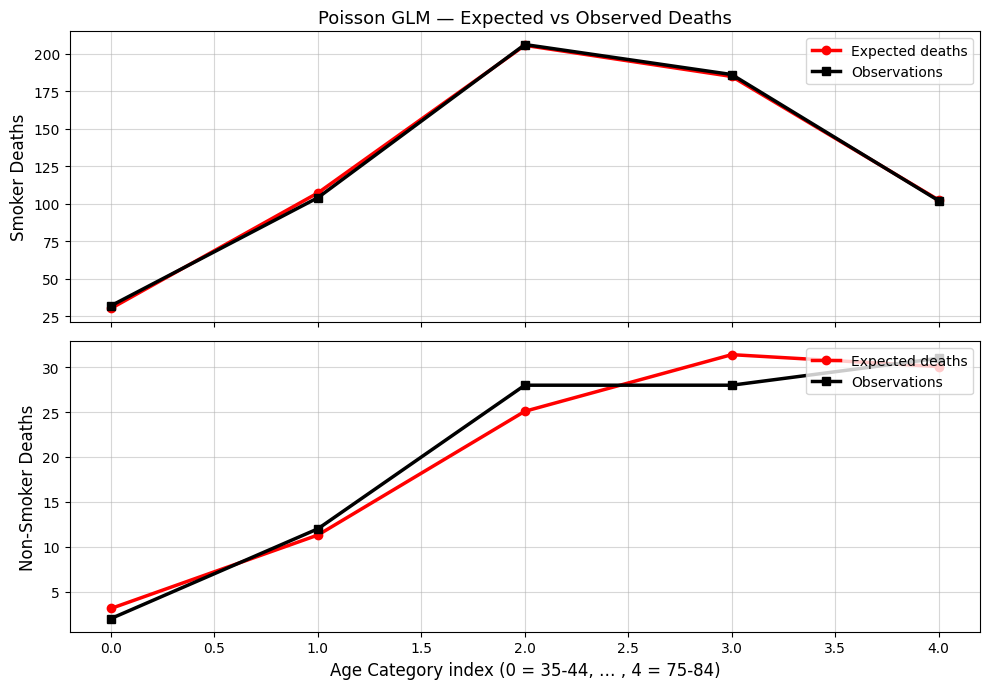

In [5]:
y     = ds['Deaths'].values
y_avg = poisson_results.predict()

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# Top: Smokers (rows 0-4)
axes[0].plot(y_avg[0:5], 'r-', linewidth=2.5, marker='o', label='Expected deaths')
axes[0].plot(y[0:5],     'k',  linewidth=2.5, marker='s', label='Observations')
axes[0].set_ylabel('Smoker Deaths', fontsize=12)
axes[0].legend(loc='upper right'); axes[0].grid(True, alpha=0.5)
axes[0].set_title('Poisson GLM — Expected vs Observed Deaths', fontsize=13)

# Bottom: Non-smokers (rows 5-9)
axes[1].plot(y_avg[5:10], 'r-', linewidth=2.5, marker='o', label='Expected deaths')
axes[1].plot(y[5:10],     'k',  linewidth=2.5, marker='s', label='Observations')
axes[1].set_ylabel('Non-Smoker Deaths', fontsize=12)
axes[1].set_xlabel('Age Category index (0 = 35-44, … , 4 = 75-84)', fontsize=12)
axes[1].legend(loc='upper right'); axes[1].grid(True, alpha=0.5)

plt.tight_layout()
plt.savefig('images/Q3_smokers_poisson.png', dpi=130)
plt.show()


### Goodness-of-fit discussion (for the write-up)

The deviance and Pearson chi-squared statistics printed above are both measures of how far the observed counts are from the model's expected counts:

- **Deviance / df_resid ≈ 1** → the Poisson variance assumption holds.
- **Deviance / df_resid ≫ 1** → overdispersion — a Negative Binomial GLM would be more appropriate.

With only 10 observations the degrees of freedom are very small, so the summary should be interpreted with care; the tight alignment between expected and observed deaths in both panels of the figure above is the strongest visual evidence that the model captures the smoking × age interaction well.
